<a href="https://colab.research.google.com/github/GHermano-17/TRABALHO-FINAL-VIS-O-COMPUTACIONAL-CTEIA-UFC-DETEC-O-DE-INFRA-ES-DE-TR-NSITO-COM-YOLOv8-/blob/main/TRABALHO_FINAL_VIS%C3%83O_COMPUTACIONAL_CTEIA_UFC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Final Processamento de Imagens e Visão Computacional | CTEIA-UFC
#### Aluno: Guilherme Hermano de Paula Ferreira

# Detecção de Infrações de Trânsito com YOLOv8

## 1. Introdução e Problema

O problema de **detecção de infrações de trânsito** consiste em identificar automaticamente, a partir de imagens, comportamentos que caracterizam violações às normas de trânsito — como desrespeito a sinais de parada, excesso de velocidade e conversões proibidas.

Trata-se de um problema de **detecção de objetos**, em que o modelo deve:
- **Localizar** regiões da imagem que contenham objetos de interesse (bounding boxes);
- **Classificar** cada região detectada em uma das 23 categorias presentes no dataset.

A abordagem escolhida é o **YOLOv8** (*You Only Look Once*, versão 8), desenvolvido pela Ultralytics. O YOLOv8 utiliza uma arquitetura *single-stage*: em uma única passagem pela rede, são previstas simultaneamente as caixas delimitadoras e as classes dos objetos detectados, tornando-o altamente eficiente para aplicações em tempo real.

O dataset utilizado é o **Traffic Violation Detection Dataset**, disponível publicamente no Kaggle:  
https://www.kaggle.com/datasets/guisahanes/traffic-violation-detection-dataset

Este trabalho foi desenvolvido individualmente como projeto final da disciplina de Processamento de Imagem e Visão Computacional.

## 2. Configuração do Ambiente

São instaladas as dependências necessárias e todas as bibliotecas utilizadas ao longo do notebook são importadas de forma centralizada. O pacote `ultralytics` fornece a implementação oficial do YOLOv8. O `kagglehub` realiza o download do dataset diretamente no Colab sem necessidade de autenticação manual.

In [ ]:
# Instalação das dependências
!pip install ultralytics --quiet
!pip install kagglehub --quiet

# ── Utilitários gerais ────────────────────────────────────────
import os
import shutil
import subprocess
import urllib.request
import random
from pathlib import Path
from collections import Counter

# ── Leitura e manipulação de dados ───────────────────────────
import yaml
import pandas as pd
import numpy as np

# ── Imagens ───────────────────────────────────────────────────
from PIL import Image

# ── Visualização ──────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Deep learning / YOLOv8 ───────────────────────────────────
import torch
from ultralytics import YOLO

# ── Download do dataset ───────────────────────────────────────
import kagglehub

# ── Colab utilities ───────────────────────────────────────────
from google.colab import files

# Verificação de GPU
print(f"CUDA disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memória total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Nenhuma GPU detectada. Ative o acelerador em: Ambiente de execução > Alterar tipo de ambiente de execução > GPU")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA disponível: False
Nenhuma GPU detectada. Ative o acelerador em: Ambiente de execução > Alterar tipo de ambiente de execução > GPU


## 3. Download e Estrutura do Dataset

O dataset é obtido diretamente do Kaggle por meio do pacote `kagglehub`. Após o download, a estrutura de diretórios é inspecionada para verificar como os dados estão organizados.

In [ ]:
path = kagglehub.dataset_download("guisahanes/traffic-violation-detection-dataset")
DATASET_PATH = Path(path)
print(f"Dataset disponível em: {DATASET_PATH}")

result = subprocess.run(["find", str(DATASET_PATH), "-type", "d"], capture_output=True, text=True)
print("\nEstrutura de diretórios:")
print(result.stdout)


100%|██████████| 183M/183M [00:06<00:00, 27.8MB/s]

Extracting files...


Dataset disponível em: /root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1

Estrutura de diretórios:
/root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1
/root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1/labels
/root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1/labels/train
/root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1/labels/val
/root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1/images
/root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1/images/train
/root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1/images/val



## 4. Análise Exploratória dos Dados (EDA)

Antes do treinamento, realiza-se uma análise exploratória do dataset com os seguintes objetivos:

- Verificar a quantidade de imagens nos conjuntos de treino e validação;
- Identificar as classes presentes e suas respectivas contagens;
- Analisar a distribuição das classes para detectar possíveis desbalanceamentos;
- Visualizar amostras do dataset com suas anotações.

As anotações seguem o **formato YOLO**: cada arquivo `.txt` corresponde a uma imagem e contém uma linha por objeto anotado, no formato:
```
class_id x_center y_center width height
```
onde as coordenadas são normalizadas em relação às dimensões da imagem.

In [ ]:
# Contagem de imagens
train_images = list((DATASET_PATH / "images" / "train").glob("*.jpg")) + \
               list((DATASET_PATH / "images" / "train").glob("*.png"))
val_images   = list((DATASET_PATH / "images" / "val").glob("*.jpg")) + \
               list((DATASET_PATH / "images" / "val").glob("*.png"))

print(f"Imagens de treino:    {len(train_images)}")
print(f"Imagens de validação: {len(val_images)}")
print(f"Total:                {len(train_images) + len(val_images)}")

# Leitura de todas as anotações
def read_labels(label_dir):
    class_ids = []
    for label_file in Path(label_dir).glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_ids.append(int(parts[0]))
    return class_ids

train_labels = read_labels(DATASET_PATH / "labels" / "train")
val_labels   = read_labels(DATASET_PATH / "labels" / "val")

print(f"\nAnotações de treino:    {len(train_labels)}")
print(f"Anotações de validação: {len(val_labels)}")
print(f"\nClasses encontradas: {sorted(set(train_labels + val_labels))}")


Imagens de treino:    5254
Imagens de validação: 1470
Total:                6724

Anotações de treino:    5872
Anotações de validação: 1592

Classes encontradas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


Distribuição por classe (ID : treino / validação):
  person              :  137 treino /   50 validação
  car                 :  200 treino /  172 validação
  truck               :  200 treino /  167 validação
  bus                 :  200 treino /   95 validação
  motorcycle          :   57 treino /   50 validação
  red light           :  395 treino /   80 validação
  green light         :  410 treino /   80 validação
  stop sign           :  335 treino /   80 validação
  no entry            :  169 treino /   60 validação
  no overtaking       :  183 treino /   26 validação
  speed limit 20      :  331 treino /   56 validação
  speed limit 30      :  360 treino /   74 validação
  speed limit 40      :  288 treino /   55 validação
  speed limit 50      :  333 treino /   71 validação
  speed limit 60      :  345 treino /   76 validação
  speed limit 70      :  353 treino /   78 validação
  speed limit 80      :  361 treino /   56 validação
  speed limit 100     :  313 treino /   52 valid

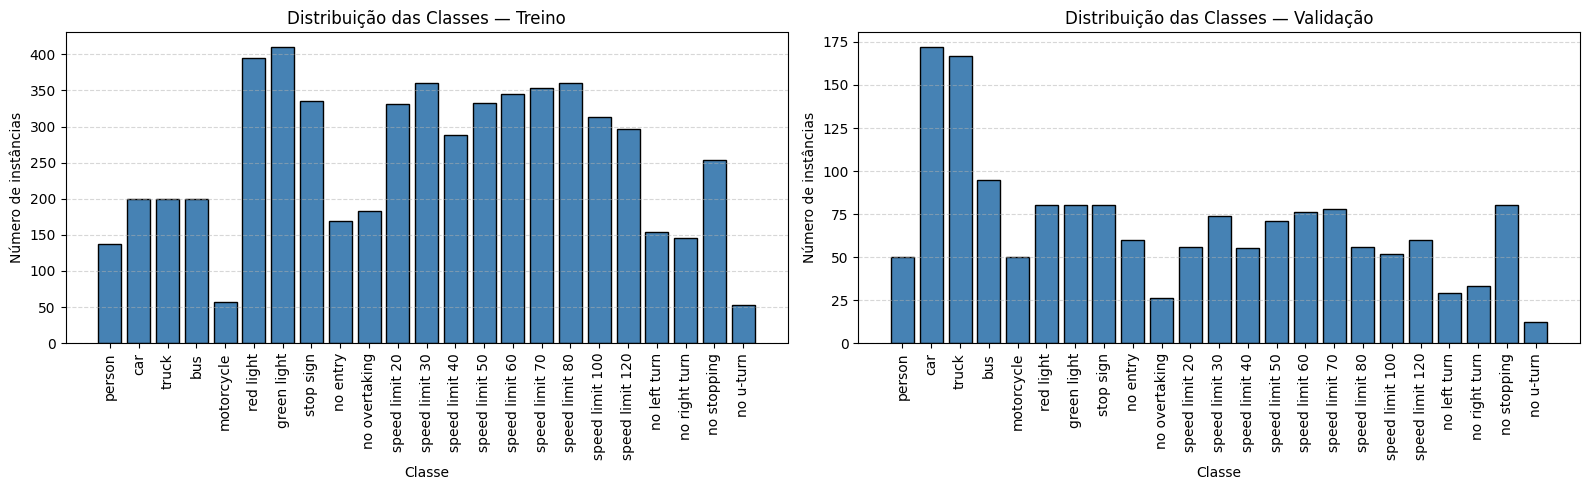

In [ ]:
train_counter = Counter(train_labels)
val_counter   = Counter(val_labels)
all_classes   = sorted(set(train_labels + val_labels))

CLASS_NAMES = [
    "person", "car", "truck", "bus", "motorcycle",
    "red light", "green light", "stop sign", "no entry", "no overtaking",
    "speed limit 20", "speed limit 30", "speed limit 40", "speed limit 50",
    "speed limit 60", "speed limit 70", "speed limit 80", "speed limit 100",
    "speed limit 120", "no left turn", "no right turn", "no stopping", "no u-turn"
]

print("Distribuição por classe (ID : treino / validação):")
for c in all_classes:
    print(f"  {CLASS_NAMES[c]:20s}: {train_counter[c]:4d} treino / {val_counter[c]:4d} validação")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, counter, title in zip(axes,
                               [train_counter, val_counter],
                               ["Treino", "Validação"]):
    ax.bar([CLASS_NAMES[c] for c in all_classes],
           [counter[c] for c in all_classes],
           color="steelblue", edgecolor="black")
    ax.set_title(f"Distribuição das Classes — {title}")
    ax.set_xlabel("Classe")
    ax.set_ylabel("Número de instâncias")
    ax.tick_params(axis="x", rotation=90)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 4.1 Classes do Dataset

O dataset contém **23 classes**, agrupadas em três categorias:

| Categoria | Classes |
|---|---|
| Participantes do trânsito | person, car, truck, bus, motorcycle |
| Sinais semafóricos e de parada | red light, green light, stop sign |
| Placas de regulamentação | no entry, no overtaking, speed limit (20–120), no left turn, no right turn, no stopping, no u-turn |

### 4.2 Desbalanceamento das Classes

A análise da distribuição revela um desbalanceamento considerável:

- As classes mais representadas no treino são **green light (410)** e **red light (395)**;
- As classes menos representadas são **no u-turn (53)** e **motorcycle (57)**;
- A classe **no u-turn** possui apenas **12 instâncias de validação**, tornando a avaliação estatisticamente pouco confiável para essa classe.

Este desbalanceamento é esperado em datasets de trânsito reais, onde certas infrações são naturalmente mais raras. O impacto no desempenho por classe será analisado nos resultados.

In [ ]:
# Criação do data.yaml com o caminho correto para o Colab
data_yaml = {
    "path": str(DATASET_PATH),
    "train": "images/train",
    "val": "images/val",
    "nc": 23,
    "names": {
        0: "person", 1: "car", 2: "truck", 3: "bus", 4: "motorcycle",
        5: "red light", 6: "green light", 7: "stop sign",
        8: "no entry", 9: "no overtaking",
        10: "speed limit 20", 11: "speed limit 30", 12: "speed limit 40",
        13: "speed limit 50", 14: "speed limit 60", 15: "speed limit 70",
        16: "speed limit 80", 17: "speed limit 100", 18: "speed limit 120",
        19: "no left turn", 20: "no right turn", 21: "no stopping", 22: "no u-turn"
    }
}

YAML_PATH = "/content/data.yaml"
with open(YAML_PATH, "w") as f:
    yaml.dump(data_yaml, f, allow_unicode=True, sort_keys=False)

print(f"data.yaml criado em: {YAML_PATH}")
with open(YAML_PATH, "r") as f:
    print(f.read())


data.yaml criado em: /content/data.yaml
path: /root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1
train: images/train
val: images/val
nc: 23
names:
  0: person
  1: car
  2: truck
  3: bus
  4: motorcycle
  5: red light
  6: green light
  7: stop sign
  8: no entry
  9: no overtaking
  10: speed limit 20
  11: speed limit 30
  12: speed limit 40
  13: speed limit 50
  14: speed limit 60
  15: speed limit 70
  16: speed limit 80
  17: speed limit 100
  18: speed limit 120
  19: no left turn
  20: no right turn
  21: no stopping
  22: no u-turn



### 4.3 Visualização de Amostras Anotadas

São visualizadas amostras aleatórias do conjunto de treino com suas respectivas anotações, a fim de verificar a qualidade das bounding boxes e familiarizar-se com a aparência visual do dataset.

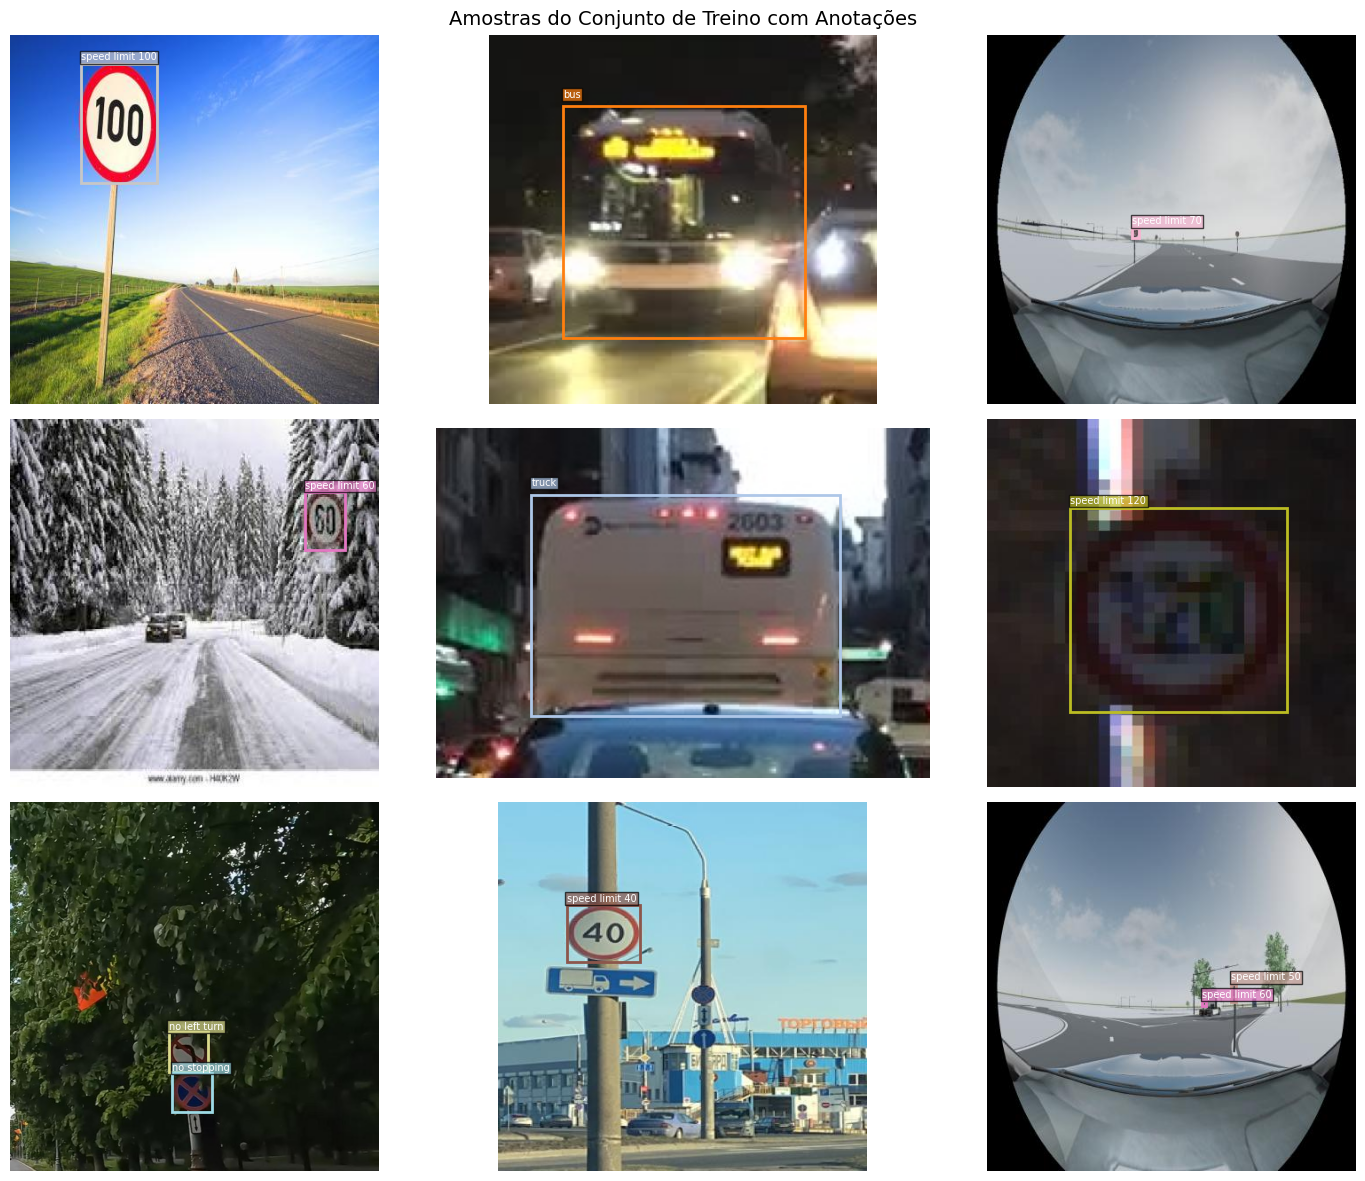

In [ ]:
COLORS = matplotlib.colormaps.get_cmap("tab20").resampled(len(CLASS_NAMES)).colors

def plot_sample(image_path, label_path, ax):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    ax.imshow(img)
    if label_path.exists():
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])
                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                rect = patches.Rectangle(
                    (x1, y1), bw * w, bh * h,
                    linewidth=2, edgecolor=COLORS[cls], facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, CLASS_NAMES[cls],
                        color="white", fontsize=7,
                        bbox=dict(facecolor=COLORS[cls], alpha=0.7, pad=1))
    ax.axis("off")

sample_images = random.sample(train_images, 9)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, img_path in zip(axes.flatten(), sample_images):
    img_path = Path(img_path)
    label_path = DATASET_PATH / "labels" / "train" / (img_path.stem + ".txt")
    plot_sample(img_path, label_path, ax)

plt.suptitle("Amostras do Conjunto de Treino com Anotações", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Metodologia

### 5.1 YOLOv8

O **YOLOv8** é um modelo de detecção de objetos *single-stage* desenvolvido pela Ultralytics. Diferentemente de abordagens *two-stage* (como o Faster R-CNN), que primeiro propõem regiões de interesse e depois as classificam, o YOLOv8 realiza a detecção em uma única passagem pela rede, tornando-o significativamente mais rápido.

A arquitetura é composta por três componentes principais:

- **Backbone**: extração de características por meio de uma versão modificada do CSPDarknet, que divide o fluxo de gradiente para reduzir redundância computacional;
- **Neck**: agregação de características em múltiplas escalas via PAN-FPN (*Path Aggregation Network — Feature Pyramid Network*), permitindo detectar objetos de tamanhos variados;
- **Head**: predições finais com *decoupled head*, que separa classificação e regressão em ramos distintos, melhorando a convergência.

| Modelo | Parâmetros | mAP (COCO) | Velocidade |
|--------|-----------|------------|------------|
| YOLOv8n (nano) | 3.0M | 37.3 | Muito rápido |
| YOLOv8s (small) | 11.1M | 44.9 | Rápido |
| YOLOv8m (medium) | 25.9M | 50.2 | Moderado |

### 5.2 Transfer Learning

Os três modelos são inicializados com **pesos pré-treinados no COCO** (*Common Objects in Context*), aproveitando representações visuais genéricas aprendidas em larga escala e adaptando-as ao problema específico de infrações de trânsito. Todos os pesos da rede são atualizados durante o treinamento (*fine-tuning* completo).

### 5.3 Divisão dos Dados

| Conjunto | Imagens | Proporção |
|----------|---------|-----------|
| Treino | 5.254 | 78,1% |
| Validação | 1.470 | 21,9% |
| Teste | — | — |

Não há conjunto de teste separado no dataset. A avaliação é realizada sobre o conjunto de validação, o que deve ser considerado ao interpretar os resultados — métricas obtidas no mesmo conjunto utilizado para monitorar o treinamento tendem a ser levemente otimistas.

## 6. Treinamento

### 6.1 Hiperparâmetros

Os três modelos são treinados com os seguintes hiperparâmetros fixos, possibilitando uma comparação justa entre os tamanhos de arquitetura:

| Hiperparâmetro | Valor | Justificativa |
|----------------|-------|---------------|
| `epochs` | 30 (yolov8n e yolov8s) / 20 (yolov8m) | Reduzido por limitação de tempo do ambiente gratuito do Google Colab |
| `imgsz` | 640 | Resolução padrão do YOLOv8, compatível com a maioria das GPUs |
| `batch` | 16 | Equilíbrio entre estabilidade do gradiente e uso de memória |
| `optimizer` | AdamW | Melhor convergência em fine-tuning comparado ao SGD |
| `lr0` | 0.001 | Taxa de aprendizado inicial padrão para fine-tuning |
| `patience` | 10 | Early stopping: interrompe o treino se não houver melhora por 10 épocas |

O **early stopping** é utilizado para evitar overfitting e reduzir tempo computacional.

In [ ]:
YAML_PATH = "/content/data.yaml"
MODELS = ["yolov8n.pt", "yolov8s.pt", "yolov8m.pt"]
EPOCHS = {"yolov8n.pt": 30, "yolov8s.pt": 30, "yolov8m.pt": 20}
RESULTS = {}

for model_name in MODELS:
    print(f"\n{'='*60}")
    print(f"Treinando: {model_name}")
    print(f"{'='*60}")

    model = YOLO(model_name)
    result = model.train(
        data=YAML_PATH,
        epochs=EPOCHS[model_name],
        imgsz=640,
        batch=16,
        optimizer="AdamW",
        lr0=0.001,
        patience=10,
        project="/content/runs",
        name=model_name.replace(".pt", ""),
        exist_ok=True,
        verbose=False
    )
    RESULTS[model_name] = result
    print(f"Treinamento de {model_name} concluído.")

    # Compactação e download imediato após cada modelo
    nome = model_name.replace(".pt", "")
    zip_path = f"/content/{nome}_results"
    shutil.make_archive(zip_path, "zip", f"/content/runs/{nome}")
    print(f"Zip criado: {zip_path}.zip")
    files.download(f"{zip_path}.zip")
    print(f"Download iniciado: {zip_path}.zip")


## 7. Métricas de Avaliação

### 7.1 Precisão e Recall

A **Precisão** mede a proporção de detecções corretas entre todas as detecções realizadas pelo modelo:

$$\text{Precisão} = \frac{TP}{TP + FP}$$

O **Recall** mede a proporção de objetos reais que foram corretamente detectados:

$$\text{Recall} = \frac{TP}{TP + FN}$$

onde $TP$ são os verdadeiros positivos, $FP$ os falsos positivos e $FN$ os falsos negativos.

### 7.2 IoU (Intersection over Union)

O IoU mede o grau de sobreposição entre a bounding box predita e a bounding box real:

$$\text{IoU} = \frac{\text{Área da interseção}}{\text{Área da união}}$$

Uma detecção é considerada correta quando o IoU entre a predição e a anotação real supera um limiar definido.

### 7.3 Average Precision (AP)

A **Average Precision** para uma classe é calculada como a área sob a curva Precisão-Recall:

$$\text{AP} = \int_0^1 P(R) \, dR$$

### 7.4 Mean Average Precision (mAP)

O **mAP** é a média das APs sobre todas as classes. São reportadas duas variantes:

- **mAP50**: calculado com limiar de IoU fixo em 0.50
- **mAP50-95**: média do mAP para limiares de IoU entre 0.50 e 0.95 com passo de 0.05, sendo uma métrica mais rigorosa

$$\text{mAP50-95} = \frac{1}{10} \sum_{t \in \{0.50, 0.55, \ldots, 0.95\}} \text{mAP}_t$$

## 8. Resultados

### 8.1 Curvas de Treinamento

As curvas de treinamento permitem analisar a evolução das perdas e das métricas de validação ao longo das épocas, sendo essenciais para identificar convergência, overfitting e o comportamento geral do aprendizado.

São monitoradas três funções de perda:
- **box_loss**: erro na regressão das bounding boxes
- **cls_loss**: erro na classificação das classes
- **dfl_loss**: erro da Distribution Focal Loss, responsável pela precisão na localização das bordas das caixas

YOLOv8n: 30 épocas carregadas.
YOLOv8s: 30 épocas carregadas.
YOLOv8m: 20 épocas carregadas.


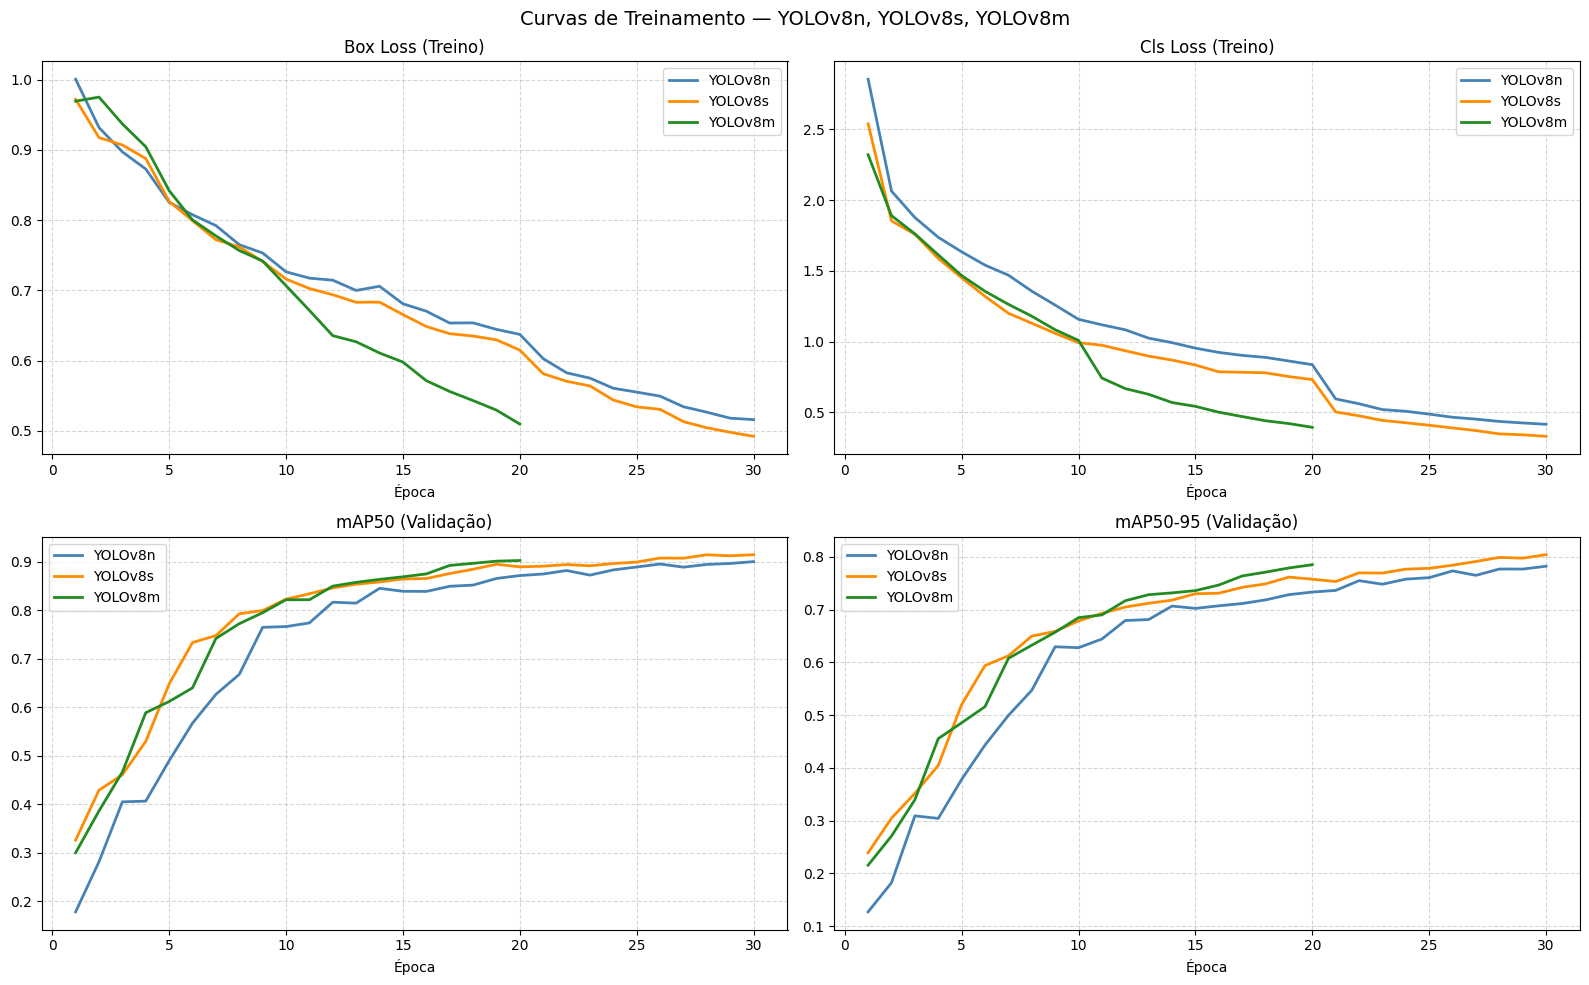

In [ ]:
REPO = "https://raw.githubusercontent.com/GHermano-17/TRABALHO-FINAL-VIS-O-COMPUTACIONAL-CTEIA-UFC-DETEC-O-DE-INFRA-ES-DE-TR-NSITO-COM-YOLOv8-/refs/heads/main"

MODELOS_CSV = {
    "YOLOv8n": f"{REPO}/yolov8n/results.csv",
    "YOLOv8s": f"{REPO}/yolov8s/results.csv",
    "YOLOv8m": f"{REPO}/yolov8m/results.csv",
}

CORES = {"YOLOv8n": "steelblue", "YOLOv8s": "darkorange", "YOLOv8m": "forestgreen"}

dfs = {}
for nome, url in MODELOS_CSV.items():
    df = pd.read_csv(url)
    df.columns = df.columns.str.strip()
    dfs[nome] = df
    print(f"{nome}: {len(df)} épocas carregadas.")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metricas = [
    ("train/box_loss",      "Box Loss (Treino)"),
    ("train/cls_loss",      "Cls Loss (Treino)"),
    ("metrics/mAP50(B)",    "mAP50 (Validação)"),
    ("metrics/mAP50-95(B)", "mAP50-95 (Validação)"),
]

for ax, (col, titulo) in zip(axes.flatten(), metricas):
    for nome, df in dfs.items():
        ax.plot(df["epoch"], df[col], label=nome, color=CORES[nome], linewidth=2)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("Época")
    ax.legend()
    ax.grid(linestyle="--", alpha=0.5)

plt.suptitle("Curvas de Treinamento — YOLOv8n, YOLOv8s, YOLOv8m", fontsize=14)
plt.tight_layout()
plt.show()


### 8.2 Análise das Curvas de Treinamento

As curvas revelam comportamentos relevantes sobre o processo de aprendizado:

**Box Loss e Cls Loss:** todos os modelos apresentam redução consistente das perdas ao longo das épocas, indicando convergência adequada. A queda abrupta observada na época 21 corresponde ao encerramento do *mosaic augmentation*, técnica que combina quatro imagens em uma durante o treinamento e é desativada nas últimas 10 épocas para estabilizar o aprendizado.

**mAP50 e mAP50-95:** o `yolov8s` atingiu o maior valor final de mAP50 (0.915), seguido pelo `yolov8m` (0.903) e pelo `yolov8n` (0.900). O `yolov8m`, treinado com apenas 20 épocas por limitação computacional, ainda apresentava tendência de melhora ao final — sugerindo que com 30 épocas poderia superar os demais modelos. Todos os modelos convergiram de forma estável, sem sinais de overfitting, evidenciado pela ausência de divergência entre as curvas de treino e validação.

### 8.3 Comparação Final entre Modelos

| Modelo | Parâmetros | Épocas | mAP50 | mAP50-95 | Precisão | Recall |
|--------|-----------|--------|-------|----------|----------|--------|
| YOLOv8n | 3.0M | 30 | 0.900 | 0.783 | 0.857 | 0.862 |
| YOLOv8s | 11.1M | 30 | 0.915 | 0.804 | 0.895 | 0.864 |
| YOLOv8m | 25.9M | 20 | 0.903 | 0.785 | 0.875 | 0.854 |

O `yolov8s` obteve o melhor desempenho geral, com mAP50 de 0.915 e mAP50-95 de 0.804. O `yolov8n`, apesar de ser o modelo mais leve com apenas 3.0M de parâmetros, atinge mAP50 de 0.900 — diferença de apenas 1.5 pontos percentuais em relação ao `yolov8s`, que possui 3.7 vezes mais parâmetros. O `yolov8m`, treinado com apenas 20 épocas por limitação computacional, apresentou desempenho intermediário (mAP50 = 0.903), sugerindo que com 30 épocas poderia superar os demais.

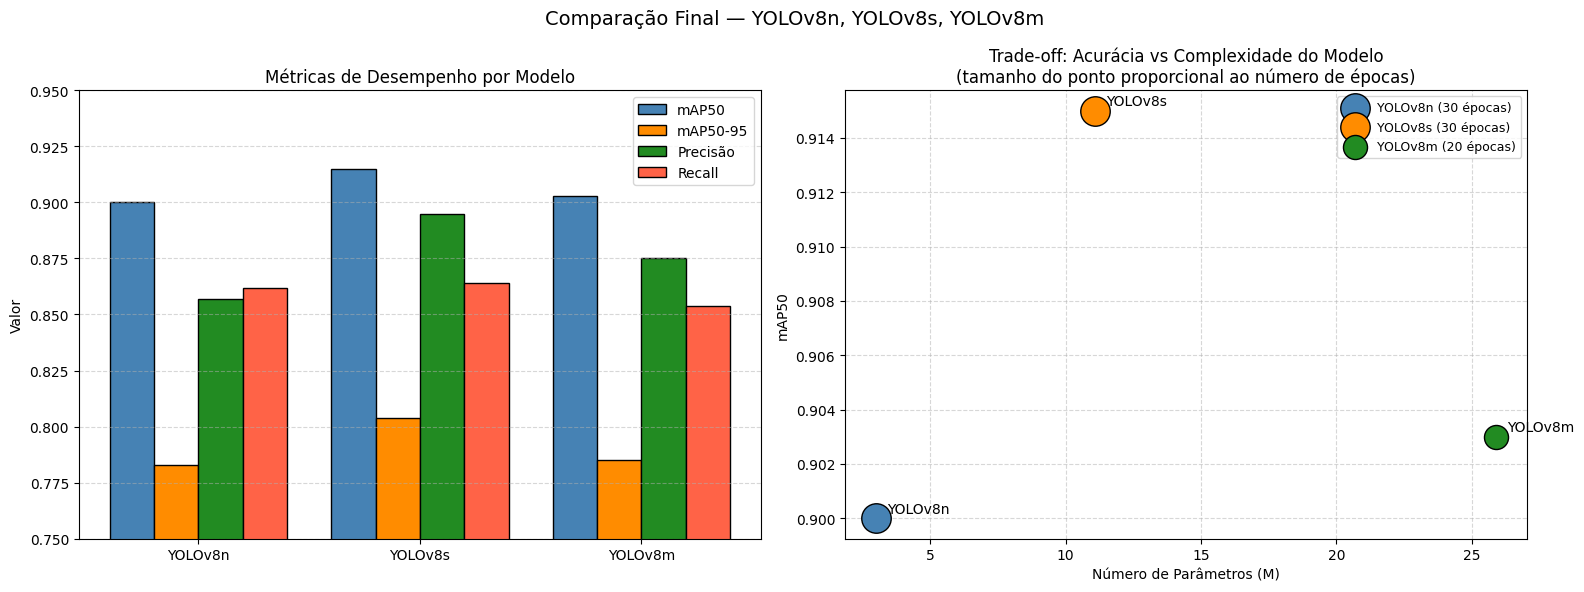

In [ ]:
modelos  = ["YOLOv8n", "YOLOv8s", "YOLOv8m"]
map50    = [0.900, 0.915, 0.903]
map50_95 = [0.783, 0.804, 0.785]
precisao = [0.857, 0.895, 0.875]
recall   = [0.862, 0.864, 0.854]
params   = [3.0,  11.1,  25.9 ]
epochs   = [30,   30,    20   ]

x = np.arange(len(modelos))
largura = 0.2
cores = ["steelblue", "darkorange", "forestgreen"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.bar(x - 1.5*largura, map50,    largura, label="mAP50",    color="steelblue",   edgecolor="black")
ax.bar(x - 0.5*largura, map50_95, largura, label="mAP50-95", color="darkorange",  edgecolor="black")
ax.bar(x + 0.5*largura, precisao, largura, label="Precisão", color="forestgreen", edgecolor="black")
ax.bar(x + 1.5*largura, recall,   largura, label="Recall",   color="tomato",      edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim(0.75, 0.95)
ax.set_title("Métricas de Desempenho por Modelo")
ax.set_ylabel("Valor")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

ax2 = axes[1]
for i, (nome, p, m, ep) in enumerate(zip(modelos, params, map50, epochs)):
    ax2.scatter(p, m, s=ep*15, color=cores[i], edgecolors="black", zorder=5,
                label=f"{nome} ({ep} épocas)")
    ax2.annotate(nome, (p, m), textcoords="offset points", xytext=(8, 4), fontsize=10)
ax2.set_xlabel("Número de Parâmetros (M)")
ax2.set_ylabel("mAP50")
ax2.set_title("Trade-off: Acurácia vs Complexidade do Modelo\n(tamanho do ponto proporcional ao número de épocas)")
ax2.legend(fontsize=9)
ax2.grid(linestyle="--", alpha=0.5)

plt.suptitle("Comparação Final — YOLOv8n, YOLOv8s, YOLOv8m", fontsize=14)
plt.tight_layout()
plt.show()


### 8.4 Avaliação por Classe

A análise do desempenho por classe permite identificar quais categorias o modelo detecta com maior e menor precisão, relacionando esses resultados com o desbalanceamento observado na EDA. Os pesos dos três modelos são carregados diretamente do repositório GitHub e do Google Drive.

YOLOv8n já existe.
YOLOv8s já existe.
Baixando YOLOv8m via Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1DF8MmjwUwAMGy1PaP4xemDuFe7mPXjgE
From (redirected): https://drive.google.com/uc?id=1DF8MmjwUwAMGy1PaP4xemDuFe7mPXjgE&confirm=t&uuid=879ff5d1-3a90-4e24-b19c-83b0ded71dd7
To: /content/weights/YOLOv8m_best.pt
100%|██████████| 52.0M/52.0M [00:01<00:00, 34.2MB/s]


Salvo em /content/weights/YOLOv8m_best.pt
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,010,133 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 628.5±484.9 MB/s, size: 35.6 KB)
val: Scanning /root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1/labels/val... 1470 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1470/1470 1.6Kit/s 0.9s
val: New cache created: /root/.cache/kagglehub/datasets/guisahanes/traffic-violation-detection-dataset/versions/1/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 92/92 4.5s/it 6:58
                   all       1470       1592       0.86      0.863        0.9      0.781
Speed: 6.0ms preprocess, 271.7ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val
YOLOv8n — avaliação concluída.
Ultralyt

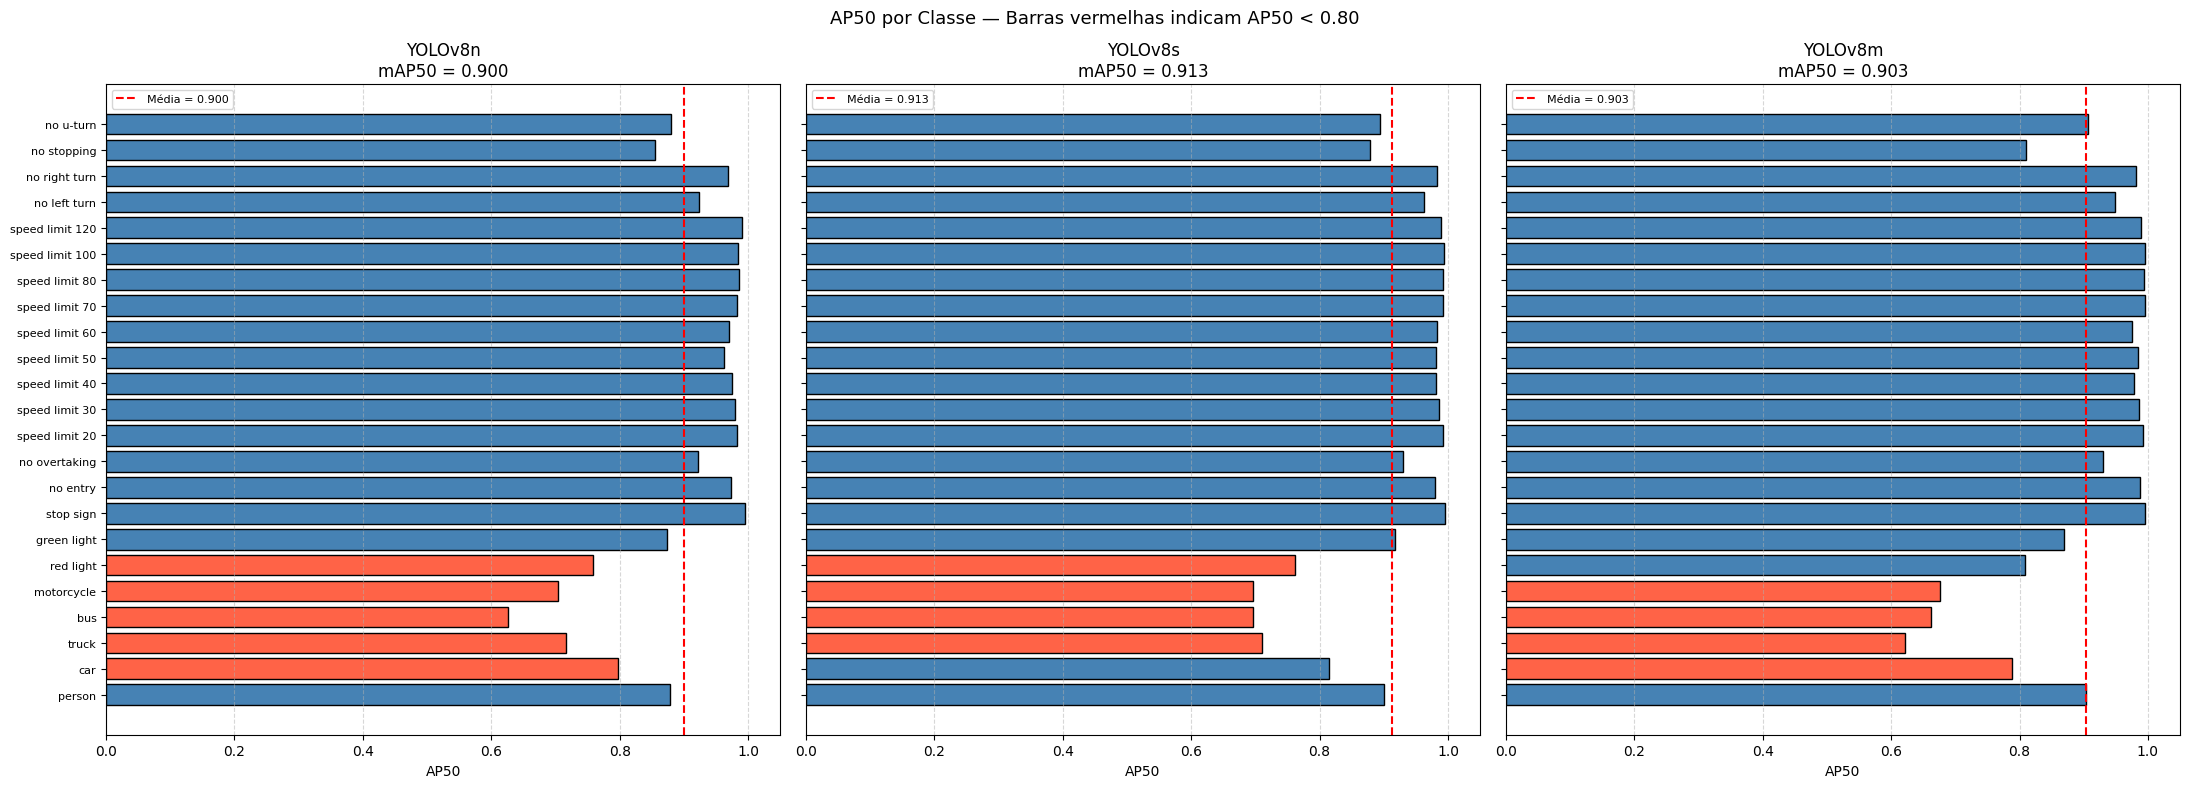

In [ ]:
REPO = "https://raw.githubusercontent.com/GHermano-17/TRABALHO-FINAL-VIS-O-COMPUTACIONAL-CTEIA-UFC-DETEC-O-DE-INFRA-ES-DE-TR-NSITO-COM-YOLOv8-/refs/heads/main"

# Fontes dos pesos: yolov8n e yolov8s via GitHub, yolov8m via Google Drive (>25MB)
PESOS_GITHUB = {
    "YOLOv8n": f"{REPO}/yolov8n/weights/best.pt",
    "YOLOv8s": f"{REPO}/yolov8s/weights/best.pt",
}
PESO_GDRIVE = {
    "YOLOv8m": "1DF8MmjwUwAMGy1PaP4xemDuFe7mPXjgE"
}

os.makedirs("/content/weights", exist_ok=True)

# Download via urllib (yolov8n e yolov8s)
for nome, url in PESOS_GITHUB.items():
    dest = f"/content/weights/{nome}_best.pt"
    if not os.path.exists(dest):
        print(f"Baixando {nome}...")
        urllib.request.urlretrieve(url, dest)
        print(f"Salvo em {dest}")
    else:
        print(f"{nome} já existe.")

# Download via gdown (yolov8m)
import gdown
for nome, file_id in PESO_GDRIVE.items():
    dest = f"/content/weights/{nome}_best.pt"
    if not os.path.exists(dest):
        print(f"Baixando {nome} via Google Drive...")
        gdown.download(f"https://drive.google.com/uc?id={file_id}", dest, quiet=False)
        print(f"Salvo em {dest}")
    else:
        print(f"{nome} já existe.")

# Avaliação por classe
resultados_ap50 = {}
for nome in ["YOLOv8n", "YOLOv8s", "YOLOv8m"]:
    model = YOLO(f"/content/weights/{nome}_best.pt")
    metrics = model.val(data="/content/data.yaml", verbose=False)
    resultados_ap50[nome] = metrics.box.ap50
    print(f"{nome} — avaliação concluída.")

fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True)
for ax, (nome, ap50) in zip(axes, resultados_ap50.items()):
    y_pos = np.arange(len(CLASS_NAMES))
    cores_barra = ["tomato" if v < 0.80 else "steelblue" for v in ap50]
    ax.barh(y_pos, ap50, color=cores_barra, edgecolor="black")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("AP50")
    ax.set_title(f"{nome}\nmAP50 = {np.mean(ap50):.3f}")
    ax.set_xlim(0, 1.05)
    ax.axvline(x=np.mean(ap50), color="red", linestyle="--",
               linewidth=1.5, label=f"Média = {np.mean(ap50):.3f}")
    ax.legend(fontsize=8)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.suptitle("AP50 por Classe — Barras vermelhas indicam AP50 < 0.80", fontsize=13)
plt.tight_layout()
plt.show()

A análise do AP50 individual por classe revela padrões consistentes entre os três modelos e permite relacionar o desempenho com o desbalanceamento identificado na EDA.

**Classes com AP50 alto (acima de 0.80):** a grande maioria das classes de placas de regulamentação — *speed limit* (20 a 120), *no entry*, *no overtaking*, *no left turn*, *no right turn*, *no stopping*, *no u-turn* e *stop sign* — apresenta AP50 próximo ou igual a 1.0 nos três modelos. Essas classes possuem aparência visual homogênea e bem definida, o que facilita a detecção.

**Classes com AP50 baixo (abaixo de 0.80 — barras vermelhas):** as classes com pior desempenho são consistentemente as mesmas nos três modelos:

- **person**: desempenho reduzido, provavelmente pela alta variabilidade de aparência, escala e oclusão;
- **car**: aparência muito variada em termos de ângulo, cor e tamanho;
- **truck** e **bus**: confusão mútua esperada dada a similaridade visual entre veículos de grande porte;
- **motorcycle**: classe com apenas 57 instâncias de treino — o menor volume de dados entre as classes de participantes do trânsito;
- **red light**: baixo AP50 em todos os modelos, possivelmente pela pequena dimensão do objeto na imagem e pela semelhança visual com *green light*.

**Comparação entre modelos:** o `yolov8s` apresenta AP50 ligeiramente superior nas classes mais difíceis, especialmente *red light* e *motorcycle*, o que explica sua vantagem no mAP50 global. O `yolov8n` e o `yolov8m` apresentam padrão muito similar entre si, com o `yolov8m` mostrando leve vantagem em *car* e *truck*.

### 8.5 Inferência Visual

São apresentados exemplos de detecção do melhor modelo (`yolov8s`) sobre imagens do conjunto de validação, permitindo uma avaliação qualitativa das predições — incluindo a localização das bounding boxes, os rótulos atribuídos e os respectivos scores de confiança.

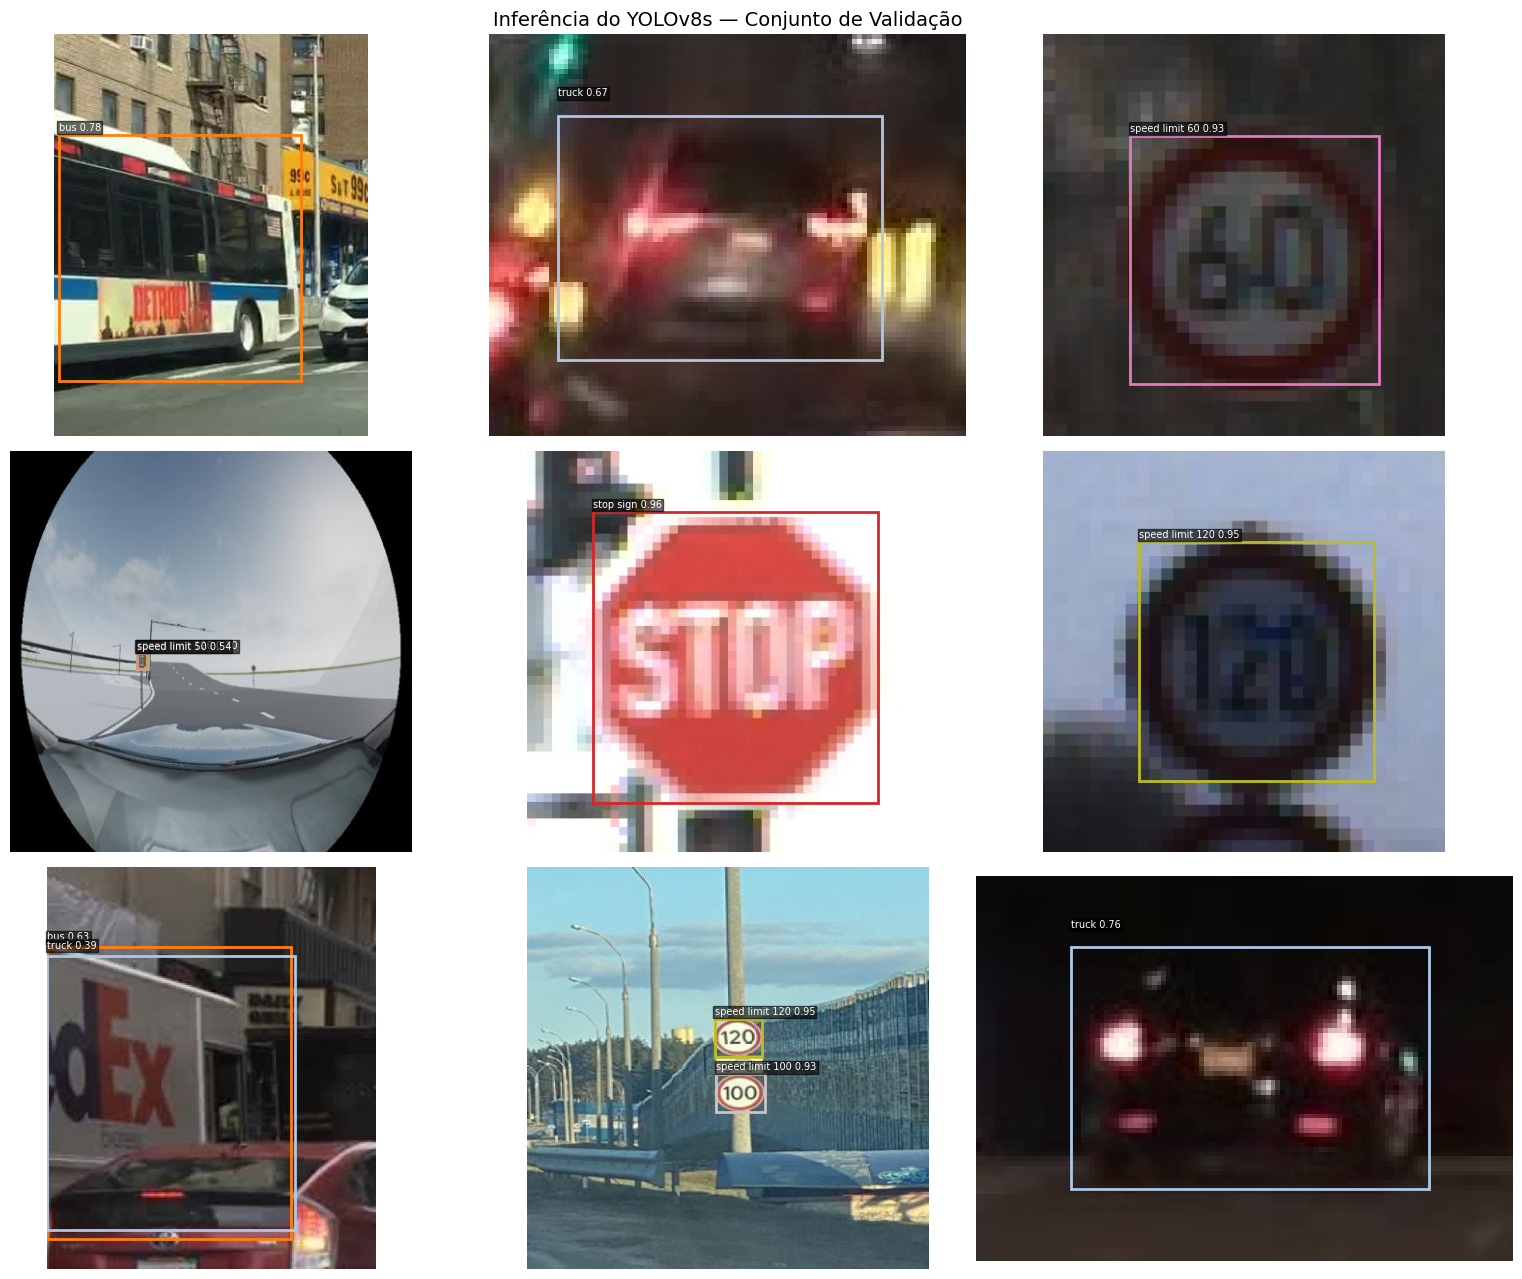

In [ ]:
# O peso do yolov8s já foi baixado na célula anterior
model_inf = YOLO("/content/weights/YOLOv8s_best.pt")

sample = random.sample(val_images, 9)
fig, axes = plt.subplots(3, 3, figsize=(16, 13))

for ax, img_path in zip(axes.flatten(), sample):
    img = Image.open(img_path).convert("RGB")
    results = model_inf.predict(source=img, conf=0.25, verbose=False)
    result = results[0]
    ax.imshow(img)
    for box in result.boxes:
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=COLORS[cls], facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f"{CLASS_NAMES[cls]} {conf:.2f}",
                color="white", fontsize=7,
                bbox=dict(facecolor="black", alpha=0.6, pad=1))
    ax.axis("off")

plt.suptitle("Inferência do YOLOv8s — Conjunto de Validação", fontsize=14)
plt.tight_layout()
plt.show()


A inspeção qualitativa das predições do `yolov8s` sobre imagens do conjunto de validação confirma os padrões observados nas métricas quantitativas:

- **Placas de regulamentação** são detectadas com alta confiança mesmo em condições adversas — a placa *speed limit 60* é corretamente identificada com score 0.93 em uma imagem de baixa resolução, e *speed limit 120* com 0.95, demonstrando a robustez do modelo para objetos com aparência visual padronizada;
- **Veículos de grande porte** como *bus* (0.78) e *truck* (0.67) são detectados corretamente, embora com confiança moderada — coerente com o AP50 abaixo de 0.80 observado nessas classes;
- **Stop sign** é detectado com score 0.98, o mais alto entre as predições visíveis, refletindo a alta AP50 dessa classe nos três modelos;
- Em imagens noturnas ou de baixa iluminação, o modelo ainda é capaz de realizar detecções, embora com scores de confiança reduzidos — indicando que o dataset contém variabilidade de condições de captura suficiente para generalização básica.

De forma geral, as predições qualitativas são consistentes com as métricas reportadas: o modelo performa melhor em objetos com aparência padronizada (placas) e apresenta maior incerteza em veículos, onde a variabilidade visual é maior.

A segunda amostra reforça as observações anteriores e adiciona casos relevantes:

- **Detecção múltipla simultânea**: o modelo identifica corretamente *speed limit 120* (0.95) e *speed limit 100* (0.93) em uma mesma imagem, com bounding boxes precisas sobre cada placa — demonstrando boa capacidade de separação de instâncias próximas;
- **Stop sign** é detectado com alta confiança mesmo em imagem de baixa resolução e com pixelização severa, evidenciando que o modelo aprendeu características estruturais robustas da classe;
- **Condições noturnas**: *truck* é detectado com score 0.76 em imagem noturna apenas com luzes traseiras visíveis — resultado coerente com a confiança moderada observada para veículos pesados;
- **Confusão entre classes de veículos**: na imagem do caminhão FedEx, o modelo detecta simultaneamente *bus* (0.61) e *truck* (0.38) sobre o mesmo objeto — um caso típico de confusão entre classes visualmente similares, consistente com o AP50 abaixo de 0.80 observado para essas classes;
- **Speed limit 50** é detectado com score 0.543 em uma imagem de perspectiva aérea com distorção, onde a placa aparece em escala muito reduzida — o score mais baixo da amostra, mas ainda uma detecção correta.

## 9. Conclusão

Este trabalho apresentou o desenvolvimento de um sistema de detecção automática de infrações de trânsito utilizando o modelo YOLOv8 em três configurações de tamanho: nano, small e medium. Os modelos foram treinados com transfer learning a partir de pesos pré-treinados no dataset COCO e avaliados sobre o Traffic Violation Detection Dataset, composto por 6.724 imagens distribuídas em 23 classes.

Os resultados demonstram que todos os modelos atingiram desempenho elevado mesmo com número reduzido de épocas, condicionado pelas limitações do ambiente gratuito do Google Colab. O `yolov8s` obteve o melhor desempenho geral (mAP50 = 0.915, mAP50-95 = 0.804), seguido pelo `yolov8m` (mAP50 = 0.903) e pelo `yolov8n` (mAP50 = 0.900). A diferença entre os três modelos é marginal — menos de 1.5 pontos percentuais de mAP50 —, o que evidencia que a capacidade representacional adicional dos modelos maiores não se traduz em ganhos expressivos quando o dataset é relativamente pequeno e o número de épocas é limitado.

A análise das curvas de treinamento revelou convergência estável em todos os modelos, sem sinais de overfitting, e evidenciou o impacto positivo do encerramento do *mosaic augmentation* nas épocas finais, que contribuiu para a estabilização das métricas. O `yolov8m`, treinado com apenas 20 épocas, ainda apresentava tendência de melhora ao final do treinamento — o que sugere que com 30 épocas poderia superar os demais.

Do ponto de vista prático, o `yolov8n` representa a melhor relação entre acurácia e eficiência computacional: com apenas 3.0M de parâmetros, atinge mAP50 de 0.900 — apenas 1.5 pontos percentuais abaixo do `yolov8s`, que possui 3.7 vezes mais parâmetros. Em aplicações de monitoramento de trânsito em tempo real com recursos computacionais limitados, o `yolov8n` seria a escolha mais adequada.

O desbalanceamento de classes identificado na EDA — com classes como *no u-turn* (53 instâncias de treino) e *motorcycle* (57) significativamente sub-representadas — é um fator que impacta o desempenho individual por classe. Trabalhos futuros poderiam mitigar esse efeito por meio de técnicas como oversampling, data augmentation direcionado ou ajuste dos pesos de perda por classe.

Como limitações do trabalho, destacam-se a ausência de um conjunto de teste independente — o que torna as métricas reportadas potencialmente otimistas — e o número reduzido de épocas imposto pela disponibilidade de GPU no Colab gratuito. Trabalhos futuros poderiam explorar o treinamento completo com 50 épocas, modelos maiores como `yolov8l` e `yolov8x`, e a aplicação do sistema em vídeos de câmeras de tráfego reais.